# 🏦 CreditSmart Analytics — Projet Machine Learning
## Prédiction du Montant de Crédit & Détection du Risque de Défaut Bancaire

**Formateur :** SALHI Abderrahman  
**Module :** Machine Learning  
**Dataset :** `credits_bancaires.csv` (612 demandes de crédit — Maroc)

---

### 📌 Contexte Métier

CreditSmart Analytics est une fintech marocaine qui développe des solutions d'IA pour les banques et organismes de microfinance. Ce projet vise à construire **deux modèles complémentaires** :

1. **Régression** : Estimer le montant optimal de crédit à accorder selon le profil client
2. **Classification** : Prédire si un client présente un risque de défaut de paiement

Ces outils permettront des décisions de crédit plus rapides, objectives et moins risquées, contribuant à réduire les créances douteuses de 20 à 40%.

---

## 📦 Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid', palette='muted')
RANDOM_STATE = 42

print('✅ Imports réalisés avec succès')

✅ Imports réalisés avec succès


In [2]:
df = pd.read_csv('credits_bancaires.csv')

print(f'📐 Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes\n')
print('--- Premières lignes ---')
display(df.head())

print('\n--- Dernières lignes ---')
display(df.tail())

print('\n--- Types de colonnes ---')
print(df.dtypes)

print('\n--- Résumé statistique ---')
display(df.describe(include='all'))

📐 Dimensions : 612 lignes × 16 colonnes

--- Premières lignes ---
   id  age  genre  ... duree_credit_mois montant_credit_mad defaut_paiement
0   1   30  Femme  ...                84               5000               1
1   2   60  Homme  ...               120               5000               0
2   3   62  Homme  ...                36               5000               1
3   4   33  Homme  ...                60               5000               1
4   5   34  Femme  ...                60              73000               0

[5 rows x 16 columns]

--- Dernières lignes ---
      id  age  genre  ... duree_credit_mois montant_credit_mad defaut_paiement
607  608   33  Homme  ...                36              55000               1
608  609   43  Homme  ...                24              71000               0
609  610   60  Homme  ...                48              47000               1
610  611   23  Homme  ...                24               5000               0
611  612   48  Femme  ...         

Colonnes avec valeurs manquantes :
                       Manquants  Pourcentage (%)
historique_credit             10             1.63
anciennete_emploi_ans          7             1.14
nb_dependants                  7             1.14
ratio_endettement              6             0.98
revenu_mensuel_mad             5             0.82

Total cellules manquantes : 35 sur 9792 (0.36%)


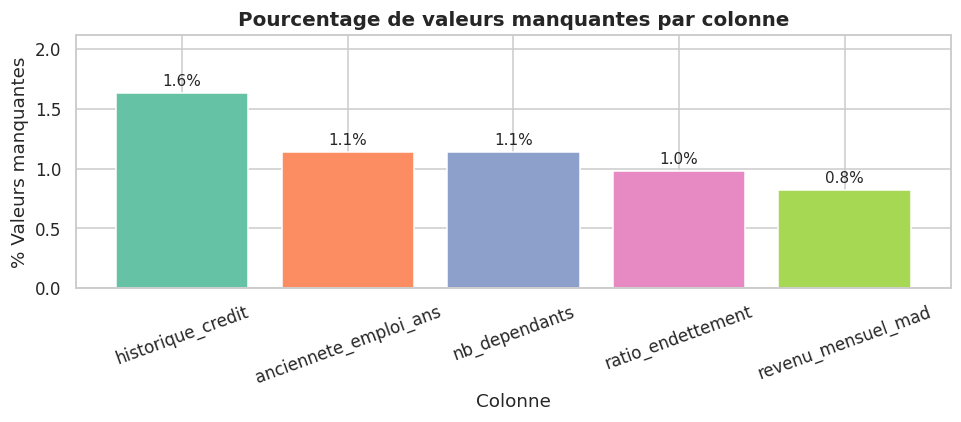

In [3]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Manquants': missing, 'Pourcentage (%)': missing_pct})
missing_df = missing_df[missing_df['Manquants'] > 0].sort_values('Manquants', ascending=False)

print('Colonnes avec valeurs manquantes :')
display(missing_df)
print(f'\nTotal cellules manquantes : {missing.sum()} sur {df.size} ({missing.sum()/df.size*100:.2f}%)')

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(missing_df.index, missing_df['Pourcentage (%)'], color=sns.color_palette('Set2', len(missing_df)))
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=10)
ax.set_title('Pourcentage de valeurs manquantes par colonne', fontsize=13, fontweight='bold')
ax.set_xlabel('Colonne')
ax.set_ylabel('% Valeurs manquantes')
ax.set_ylim(0, missing_df['Pourcentage (%)'].max() * 1.3)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [4]:
nb_doublons = df.duplicated().sum()
print(f'Lignes dupliquées détectées : {nb_doublons}')
if nb_doublons > 0:
    display(df[df.duplicated(keep=False)].sort_values('id'))

df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'\n✅ Après suppression : {df.shape[0]} lignes restantes')
print(f'Vérification — doublons restants : {df.duplicated().sum()}')

Lignes dupliquées détectées : 0

✅ Après suppression : 612 lignes restantes
Vérification — doublons restants : 0


Distribution de defaut_paiement :
  1 (Défaut de paiement) : 343 clients (56.0%)
  0 (Remboursement normal) : 269 clients (44.0%)


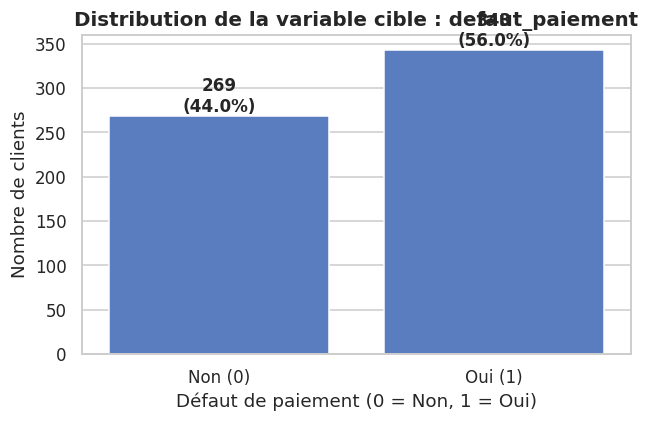

In [5]:
counts = df['defaut_paiement'].value_counts()
pcts   = df['defaut_paiement'].value_counts(normalize=True) * 100

print('Distribution de defaut_paiement :')
for k, v in counts.items():
    label = 'Remboursement normal' if k == 0 else 'Défaut de paiement'
    print(f'  {k} ({label}) : {v} clients ({pcts[k]:.1f}%)')

fig, ax = plt.subplots(figsize=(6, 4))
palette = {0: '#2ecc71', 1: "#b23325"}
bars = sns.countplot(x='defaut_paiement', data=df, ax=ax)
for p in ax.patches:
    pct = p.get_height() / len(df) * 100
    ax.annotate(f'{int(p.get_height())}\n({pct:.1f}%)',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Distribution de la variable cible : defaut_paiement', fontsize=13, fontweight='bold')
ax.set_xlabel('Défaut de paiement (0 = Non, 1 = Oui)')
ax.set_ylabel('Nombre de clients')
ax.set_xticklabels(['Non (0)', 'Oui (1)'])
plt.tight_layout()
plt.show()

Skewness : 3.770
Min : 5,000 MAD  |  Max : 556,000 MAD


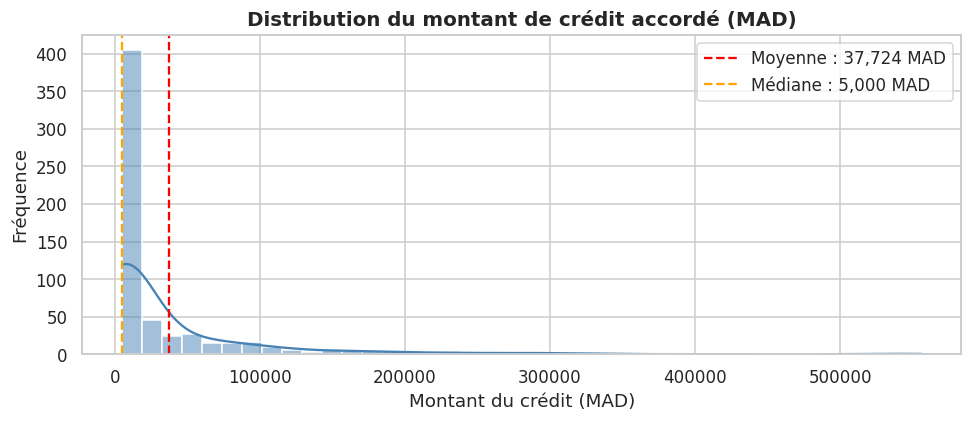

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(df['montant_credit_mad'], bins=40, kde=True, color='steelblue', ax=ax)
ax.axvline(df['montant_credit_mad'].mean(), color='red', linestyle='--', label=f'Moyenne : {df["montant_credit_mad"].mean():,.0f} MAD')
ax.axvline(df['montant_credit_mad'].median(), color='orange', linestyle='--', label=f'Médiane : {df["montant_credit_mad"].median():,.0f} MAD')
ax.set_title('Distribution du montant de crédit accordé (MAD)', fontsize=13, fontweight='bold')
ax.set_xlabel('Montant du crédit (MAD)')
ax.set_ylabel('Fréquence')
ax.legend()
plt.tight_layout()
plt.show()

skew = df['montant_credit_mad'].skew()
print(f'Skewness : {skew:.3f}')
print(f'Min : {df["montant_credit_mad"].min():,} MAD  |  Max : {df["montant_credit_mad"].max():,} MAD')

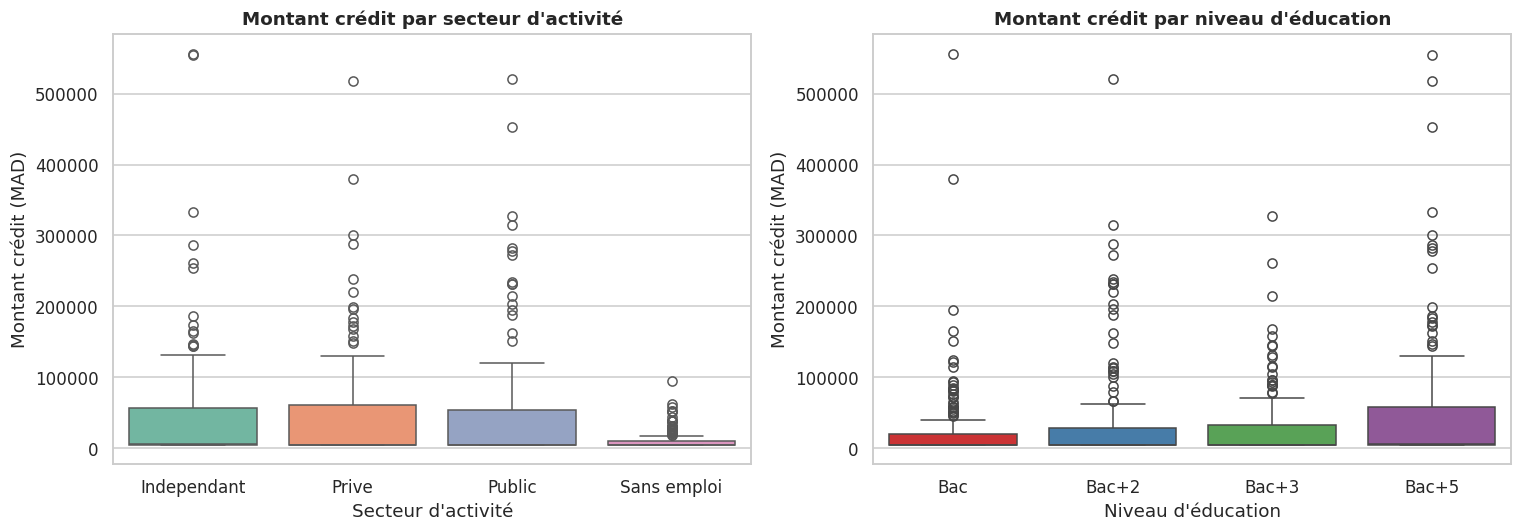

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order_secteur = df.groupby('secteur_activite')['montant_credit_mad'].median().sort_values(ascending=False).index
sns.boxplot(x='secteur_activite', y='montant_credit_mad', data=df,
            order=order_secteur, palette='Set2', ax=axes[0])
axes[0].set_title('Montant crédit par secteur d\'activité', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Secteur d\'activité')
axes[0].set_ylabel('Montant crédit (MAD)')

order_edu = ['Bac', 'Bac+2', 'Bac+3', 'Bac+5']
sns.boxplot(x='niveau_education', y='montant_credit_mad', data=df,
            order=order_edu, palette='Set1', ax=axes[1])
axes[1].set_title('Montant crédit par niveau d\'éducation', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Niveau d\'éducation')
axes[1].set_ylabel('Montant crédit (MAD)')

plt.tight_layout()
plt.show()

Corrélations avec montant_credit_mad (triées par valeur absolue) :
ratio_endettement       -0.550114
duree_credit_mois        0.311088
revenu_mensuel_mad       0.229488
nb_credits_precedents   -0.192954
anciennete_emploi_ans    0.162025
defaut_paiement         -0.105975
age                      0.076493
nb_dependants            0.006042


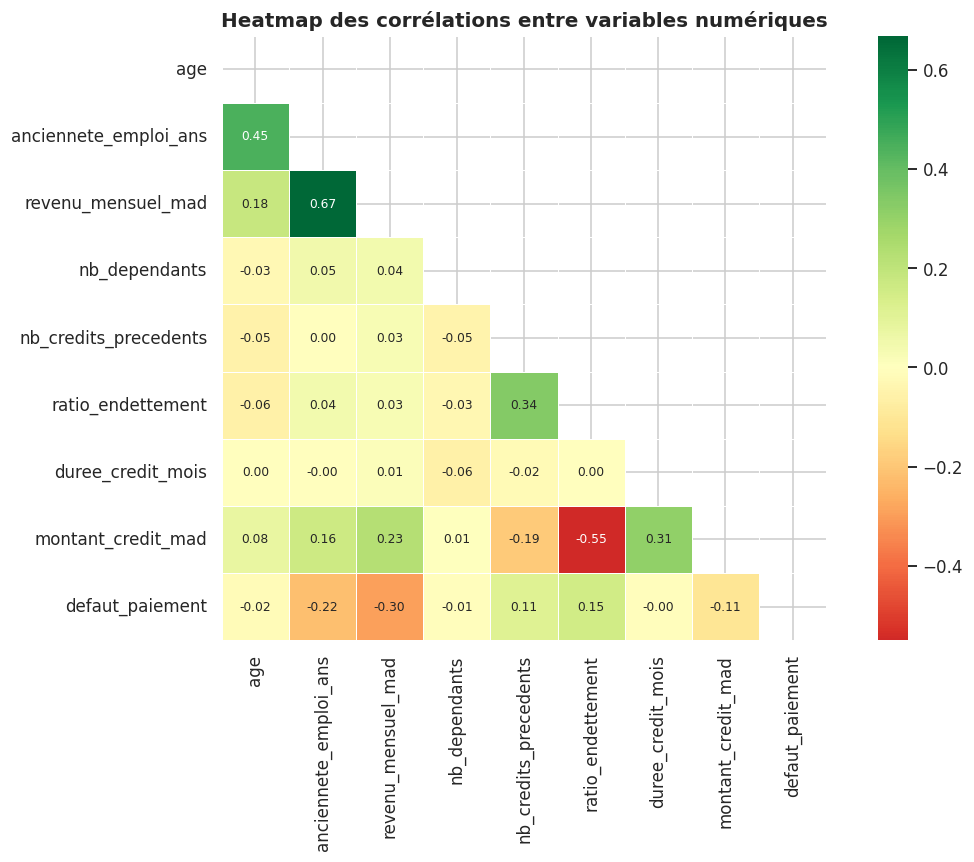

In [8]:
num_cols = df.select_dtypes(include=[np.number]).drop(columns=['id']).columns
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Heatmap des corrélations entre variables numériques', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

corr_target = corr_matrix['montant_credit_mad'].drop('montant_credit_mad').sort_values(key=abs, ascending=False)
print('Corrélations avec montant_credit_mad (triées par valeur absolue) :')
print(corr_target.to_string())

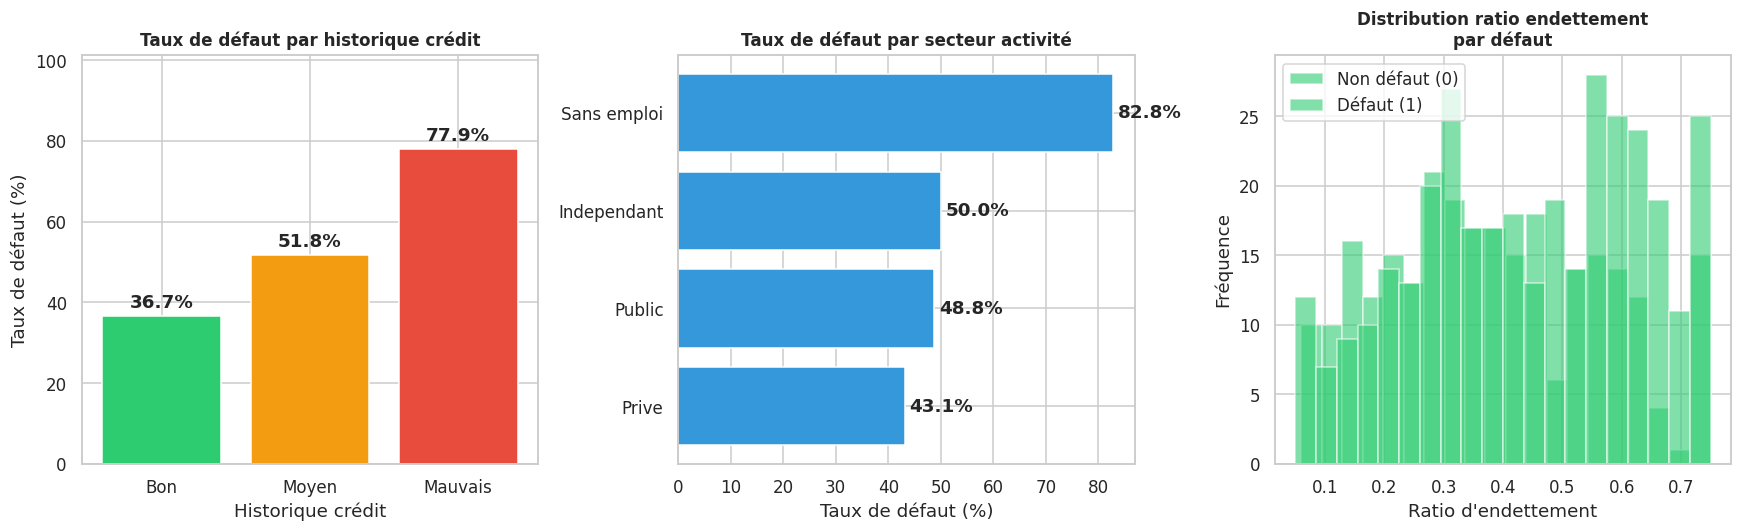

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

taux_hist = df.groupby('historique_credit')['defaut_paiement'].mean().sort_values() * 100
colors_hist = ['#2ecc71', '#f39c12', '#e74c3c'][:len(taux_hist)]
bars = axes[0].bar(taux_hist.index, taux_hist.values, color=colors_hist)
axes[0].bar_label(bars, fmt='%.1f%%', padding=3, fontweight='bold')
axes[0].set_title('Taux de défaut par historique crédit', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Historique crédit')
axes[0].set_ylabel('Taux de défaut (%)')
axes[0].set_ylim(0, taux_hist.max() * 1.3)

taux_sect = df.groupby('secteur_activite')['defaut_paiement'].mean().sort_values() * 100
bars2 = axes[1].barh(taux_sect.index, taux_sect.values, color='#3498db')
axes[1].bar_label(bars2, fmt='%.1f%%', padding=3, fontweight='bold')
axes[1].set_title('Taux de défaut par secteur activité', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Taux de défaut (%)')

df.groupby('defaut_paiement')['ratio_endettement'].plot(kind='hist', bins=20,
    alpha=0.6, ax=axes[2], label=['Non défaut (0)', 'Défaut (1)'], color=['#2ecc71','#e74c3c'])
axes[2].set_title('Distribution ratio endettement\npar défaut', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Ratio d\'endettement')
axes[2].set_ylabel('Fréquence')
axes[2].legend(['Non défaut (0)', 'Défaut (1)'])

plt.tight_layout()
plt.show()

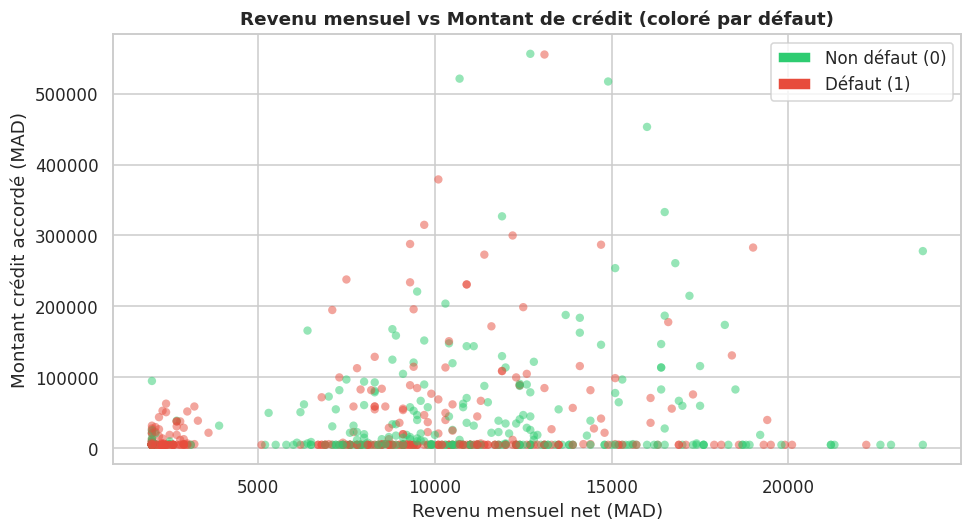

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = df['defaut_paiement'].map({0: '#2ecc71', 1: '#e74c3c'})
scatter = ax.scatter(df['revenu_mensuel_mad'], df['montant_credit_mad'],
                     c=colors, alpha=0.5, edgecolors='none', s=30)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Non défaut (0)'),
                   Patch(facecolor='#e74c3c', label='Défaut (1)')]
ax.legend(handles=legend_elements, fontsize=11)
ax.set_title('Revenu mensuel vs Montant de crédit (coloré par défaut)', fontsize=12, fontweight='bold')
ax.set_xlabel('Revenu mensuel net (MAD)')
ax.set_ylabel('Montant crédit accordé (MAD)')
plt.tight_layout()
plt.show()

In [11]:
num_missing_cols = ['anciennete_emploi_ans', 'revenu_mensuel_mad', 'nb_dependants', 'ratio_endettement']
for col in num_missing_cols:
    median_val = df[col].median()
    nb_imputed = df[col].isnull().sum()
    df[col] = df[col].fillna(median_val)
    if nb_imputed > 0:
        print(f'  {col} : {nb_imputed} valeur(s) imputée(s) par la médiane ({median_val:.2f})')

mode_hist = df['historique_credit'].mode()[0]
nb_imputed_hist = df['historique_credit'].isnull().sum()
df['historique_credit'] = df['historique_credit'].fillna(mode_hist)
if nb_imputed_hist > 0:
    print(f'  historique_credit : {nb_imputed_hist} valeur(s) imputée(s) par le mode ("{mode_hist}")')

  anciennete_emploi_ans : 7 valeur(s) imputée(s) par la médiane (5.00)
  revenu_mensuel_mad : 5 valeur(s) imputée(s) par la médiane (9300.00)
  nb_dependants : 7 valeur(s) imputée(s) par la médiane (3.00)
  ratio_endettement : 6 valeur(s) imputée(s) par la médiane (0.41)
  historique_credit : 10 valeur(s) imputée(s) par le mode ("Mauvais")


In [12]:
total_missing = df.isnull().sum().sum()
assert total_missing == 0, f'Il reste {total_missing} valeurs manquantes !'
print(f'✅ df.isnull().sum().sum() == {total_missing} — Dataset propre, aucune valeur manquante.')

✅ df.isnull().sum().sum() == 0 — Dataset propre, aucune valeur manquante.


In [13]:
outliers_revenu  = df[df['revenu_mensuel_mad'] < 0]
outliers_ratio   = df[df['ratio_endettement'] > 1]
outliers_age     = df[(df['age'] < 18) | (df['age'] > 70)]

print(f'Clients avec revenu < 0          : {len(outliers_revenu)}')
print(f'Clients avec ratio_endettement > 1 : {len(outliers_ratio)}')
print(f'Clients avec âge hors [18, 70]    : {len(outliers_age)}')

if len(outliers_ratio) > 0:
    display(outliers_ratio[['id', 'age', 'revenu_mensuel_mad', 'ratio_endettement', 'defaut_paiement']])

Clients avec revenu < 0          : 0
Clients avec ratio_endettement > 1 : 0
Clients avec âge hors [18, 70]    : 0


In [14]:
df['capacite_remboursement'] = df['revenu_mensuel_mad'] * (0.40 - df['ratio_endettement'])
df['risque_score'] = df['nb_credits_precedents'] * df['ratio_endettement']

corr_risque = df['risque_score'].corr(df['defaut_paiement'])
corr_cap    = df['capacite_remboursement'].corr(df['defaut_paiement'])
print(f'Corrélation risque_score       avec defaut_paiement : {corr_risque:.4f}')
print(f'Corrélation capacite_remboursement avec defaut_paiement : {corr_cap:.4f}')

Corrélation risque_score       avec defaut_paiement : 0.1535
Corrélation capacite_remboursement avec defaut_paiement : -0.1301


In [15]:
cat_cols = ['genre', 'ville', 'situation_familiale', 'niveau_education',
            'secteur_activite', 'historique_credit']

le = LabelEncoder()
df_encoded = df.copy()

for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])
    print(f'  {col} : {le.classes_} → {list(range(len(le.classes_)))}')

  genre : ['Femme' 'Homme'] → [0, 1]
  ville : ['Agadir' 'Casablanca' 'Fes' 'Marrakech' 'Meknes' 'Rabat' 'Tanger'] → [0, 1, 2, 3, 4, 5, 6]
  situation_familiale : ['Celibataire' 'Divorce' 'Marie' 'Veuf'] → [0, 1, 2, 3]
  niveau_education : ['Bac' 'Bac+2' 'Bac+3' 'Bac+5'] → [0, 1, 2, 3]
  secteur_activite : ['Independant' 'Prive' 'Public' 'Sans emploi'] → [0, 1, 2, 3]
  historique_credit : ['Bon' 'Mauvais' 'Moyen'] → [0, 1, 2]


In [16]:
cols_to_scale = ['age', 'anciennete_emploi_ans', 'revenu_mensuel_mad', 'nb_dependants',
                 'nb_credits_precedents', 'ratio_endettement', 'duree_credit_mois']

print('Colonnes à normaliser avec StandardScaler :')
print(cols_to_scale)

Colonnes à normaliser avec StandardScaler :
['age', 'anciennete_emploi_ans', 'revenu_mensuel_mad', 'nb_dependants', 'nb_credits_precedents', 'ratio_endettement', 'duree_credit_mois']


In [17]:
feature_cols = [c for c in df_encoded.columns
                if c not in ['id', 'defaut_paiement', 'montant_credit_mad']]

X_reg = df_encoded[feature_cols].copy()
y_reg = df_encoded['montant_credit_mad'].copy()

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Features utilisées ({len(feature_cols)}) : {feature_cols}')
print(f'\nTaille X_train : {X_reg_train.shape}  |  X_test : {X_reg_test.shape}')

Features utilisées (15) : ['age', 'genre', 'ville', 'situation_familiale', 'niveau_education', 'secteur_activite', 'anciennete_emploi_ans', 'revenu_mensuel_mad', 'nb_dependants', 'historique_credit', 'nb_credits_precedents', 'ratio_endettement', 'duree_credit_mois', 'capacite_remboursement', 'risque_score']

Taille X_train : (489, 15)  |  X_test : (123, 15)


In [18]:
scaler_reg = StandardScaler()
X_reg_train[cols_to_scale] = scaler_reg.fit_transform(X_reg_train[cols_to_scale])
X_reg_test[cols_to_scale]  = scaler_reg.transform(X_reg_test[cols_to_scale])

print('✅ StandardScaler appliqué : fit sur X_train, transform sur X_train et X_test.')

✅ StandardScaler appliqué : fit sur X_train, transform sur X_train et X_test.


In [19]:
lr = LinearRegression()
lr.fit(X_reg_train, y_reg_train)
y_pred_reg = lr.predict(X_reg_test)

mae  = mean_absolute_error(y_reg_test, y_pred_reg)
mse  = mean_squared_error(y_reg_test, y_pred_reg)
rmse = np.sqrt(mse)
r2   = r2_score(y_reg_test, y_pred_reg)

print('=== Métriques — Linear Regression (jeu de test) ===')
print(f'  MAE  (Mean Absolute Error)  : {mae:>12,.2f} MAD')
print(f'  MSE  (Mean Squared Error)   : {mse:>12,.2f}')
print(f'  RMSE (Root MSE)             : {rmse:>12,.2f} MAD')
print(f'  R²   (Coefficient déterm.)  : {r2:>12.4f}')

=== Métriques — Linear Regression (jeu de test) ===
  MAE  (Mean Absolute Error)  :    30,443.11 MAD
  MSE  (Mean Squared Error)   : 2,448,506,340.26
  RMSE (Root MSE)             :    49,482.38 MAD
  R²   (Coefficient déterm.)  :       0.5332


In [20]:
cv_scores = cross_val_score(LinearRegression(), X_reg, y_reg, cv=5, scoring='r2')
print('=== Cross-Validation (5 folds) ===')
print(f'  Scores R² par fold : {cv_scores.round(4)}')
print(f'  Moyenne            : {cv_scores.mean():.4f}')
print(f'  Écart-type         : {cv_scores.std():.4f}')

r2_train = r2_score(y_reg_train, lr.predict(X_reg_train))
print(f'\n  R² Entraînement : {r2_train:.4f}')
print(f'  R² Test         : {r2:.4f}')
print(f'  R² Cross-val    : {cv_scores.mean():.4f}')

=== Cross-Validation (5 folds) ===
  Scores R² par fold : [0.5711 0.4434 0.4963 0.582  0.5467]
  Moyenne            : 0.5279
  Écart-type         : 0.0516

  R² Entraînement : 0.5769
  R² Test         : 0.5332
  R² Cross-val    : 0.5279


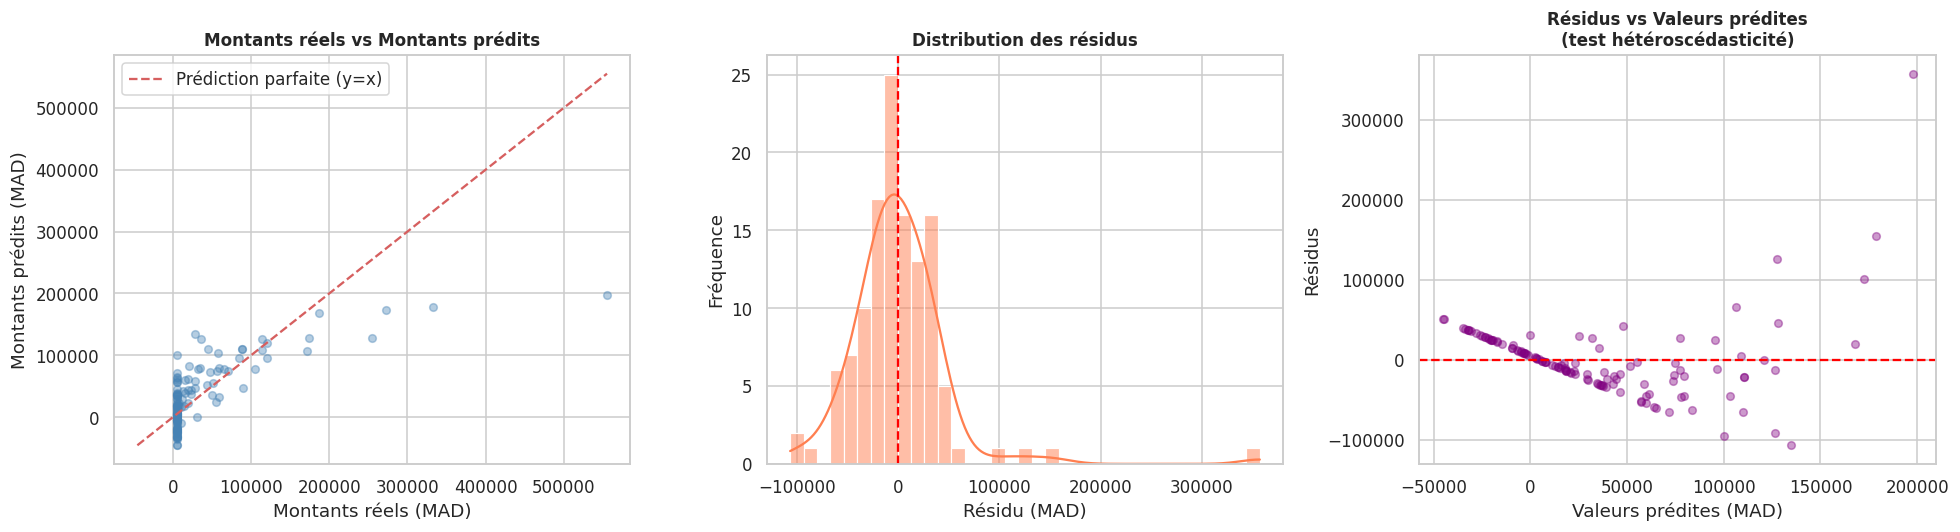

In [21]:
residus = y_reg_test.values - y_pred_reg
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_reg_test, y_pred_reg, alpha=0.4, color='steelblue', s=25)
lims = [min(y_reg_test.min(), y_pred_reg.min()), max(y_reg_test.max(), y_pred_reg.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Prédiction parfaite (y=x)')
axes[0].set_title('Montants réels vs Montants prédits', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Montants réels (MAD)')
axes[0].set_ylabel('Montants prédits (MAD)')
axes[0].legend()

sns.histplot(residus, bins=35, kde=True, color='coral', ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Distribution des résidus', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Résidu (MAD)')
axes[1].set_ylabel('Fréquence')

axes[2].scatter(y_pred_reg, residus, alpha=0.4, color='purple', s=25)
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('Résidus vs Valeurs prédites\n(test hétéroscédasticité)', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Valeurs prédites (MAD)')
axes[2].set_ylabel('Résidus')

plt.tight_layout()
plt.show()

In [22]:
feature_clf_cols = [c for c in df_encoded.columns
                    if c not in ['id', 'defaut_paiement', 'montant_credit_mad']]

X_clf = df_encoded[feature_clf_cols].copy()
y_clf = df_encoded['defaut_paiement'].copy()

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)

scaler_clf = StandardScaler()
X_clf_train[cols_to_scale] = scaler_clf.fit_transform(X_clf_train[cols_to_scale])
X_clf_test[cols_to_scale]  = scaler_clf.transform(X_clf_test[cols_to_scale])

print('Proportion de défauts dans le dataset global  :', y_clf.mean().round(4))
print('Proportion de défauts dans X_train            :', y_clf_train.mean().round(4))
print('Proportion de défauts dans X_test             :', y_clf_test.mean().round(4))

Proportion de défauts dans le dataset global  : 0.5605
Proportion de défauts dans X_train            : 0.5603
Proportion de défauts dans X_test             : 0.561


In [23]:
models = {
    'SVM'           : SVC(kernel='rbf', random_state=RANDOM_STATE),
    'KNN'           : KNeighborsClassifier(n_neighbors=5),
    'Decision Tree' : DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest' : RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
}

results = {}
for name, model in models.items():
    model.fit(X_clf_train, y_clf_train)
    y_pred = model.predict(X_clf_test)
    results[name] = {
        'model'    : model,
        'y_pred'   : y_pred,
        'accuracy' : accuracy_score(y_clf_test, y_pred),
        'precision': precision_score(y_clf_test, y_pred, average='macro', zero_division=0),
        'recall'   : recall_score(y_clf_test, y_pred, average='macro', zero_division=0),
        'f1_macro' : f1_score(y_clf_test, y_pred, average='macro', zero_division=0),
        'recall_1' : recall_score(y_clf_test, y_pred, pos_label=1, zero_division=0),
        'cm'       : confusion_matrix(y_clf_test, y_pred)
    }

print('✅ 4 modèles entraînés.')

✅ 4 modèles entraînés.


In [24]:
for name, res in results.items():
    print(f'\n{"="*50}')
    print(f'  {name}')
    print('='*50)
    print(classification_report(y_clf_test, res['y_pred'],
                                 target_names=['Non défaut (0)', 'Défaut (1)']))


  SVM
                precision    recall  f1-score   support

Non défaut (0)       0.63      0.35      0.45        54
    Défaut (1)       0.62      0.84      0.72        69

      accuracy                           0.63       123
     macro avg       0.63      0.60      0.58       123
  weighted avg       0.63      0.63      0.60       123


  KNN
                precision    recall  f1-score   support

Non défaut (0)       0.40      0.35      0.37        54
    Défaut (1)       0.53      0.58      0.56        69

      accuracy                           0.48       123
     macro avg       0.46      0.47      0.46       123
  weighted avg       0.47      0.48      0.48       123


  Decision Tree
                precision    recall  f1-score   support

Non défaut (0)       0.60      0.63      0.61        54
    Défaut (1)       0.70      0.67      0.68        69

      accuracy                           0.65       123
     macro avg       0.65      0.65      0.65       123
  weighte

In [25]:
summary = pd.DataFrame({
    name: {
        'Accuracy'      : f"{res['accuracy']:.4f}",
        'Precision Macro': f"{res['precision']:.4f}",
        'Recall Macro'  : f"{res['recall']:.4f}",
        'F1 Macro'      : f"{res['f1_macro']:.4f}",
        'Recall Classe 1': f"{res['recall_1']:.4f}"
    }
    for name, res in results.items()
}).T

print('=== Tableau de synthèse — 4 modèles de classification ===')
display(summary)

=== Tableau de synthèse — 4 modèles de classification ===
              Accuracy Precision Macro Recall Macro F1 Macro Recall Classe 1
SVM             0.6260          0.6285       0.5962   0.5842          0.8406
KNN             0.4797          0.4646       0.4658   0.4641          0.5797
Decision Tree   0.6504          0.6467       0.6481   0.6470          0.6667
Random Forest   0.7236          0.7208       0.7234   0.7213          0.7246


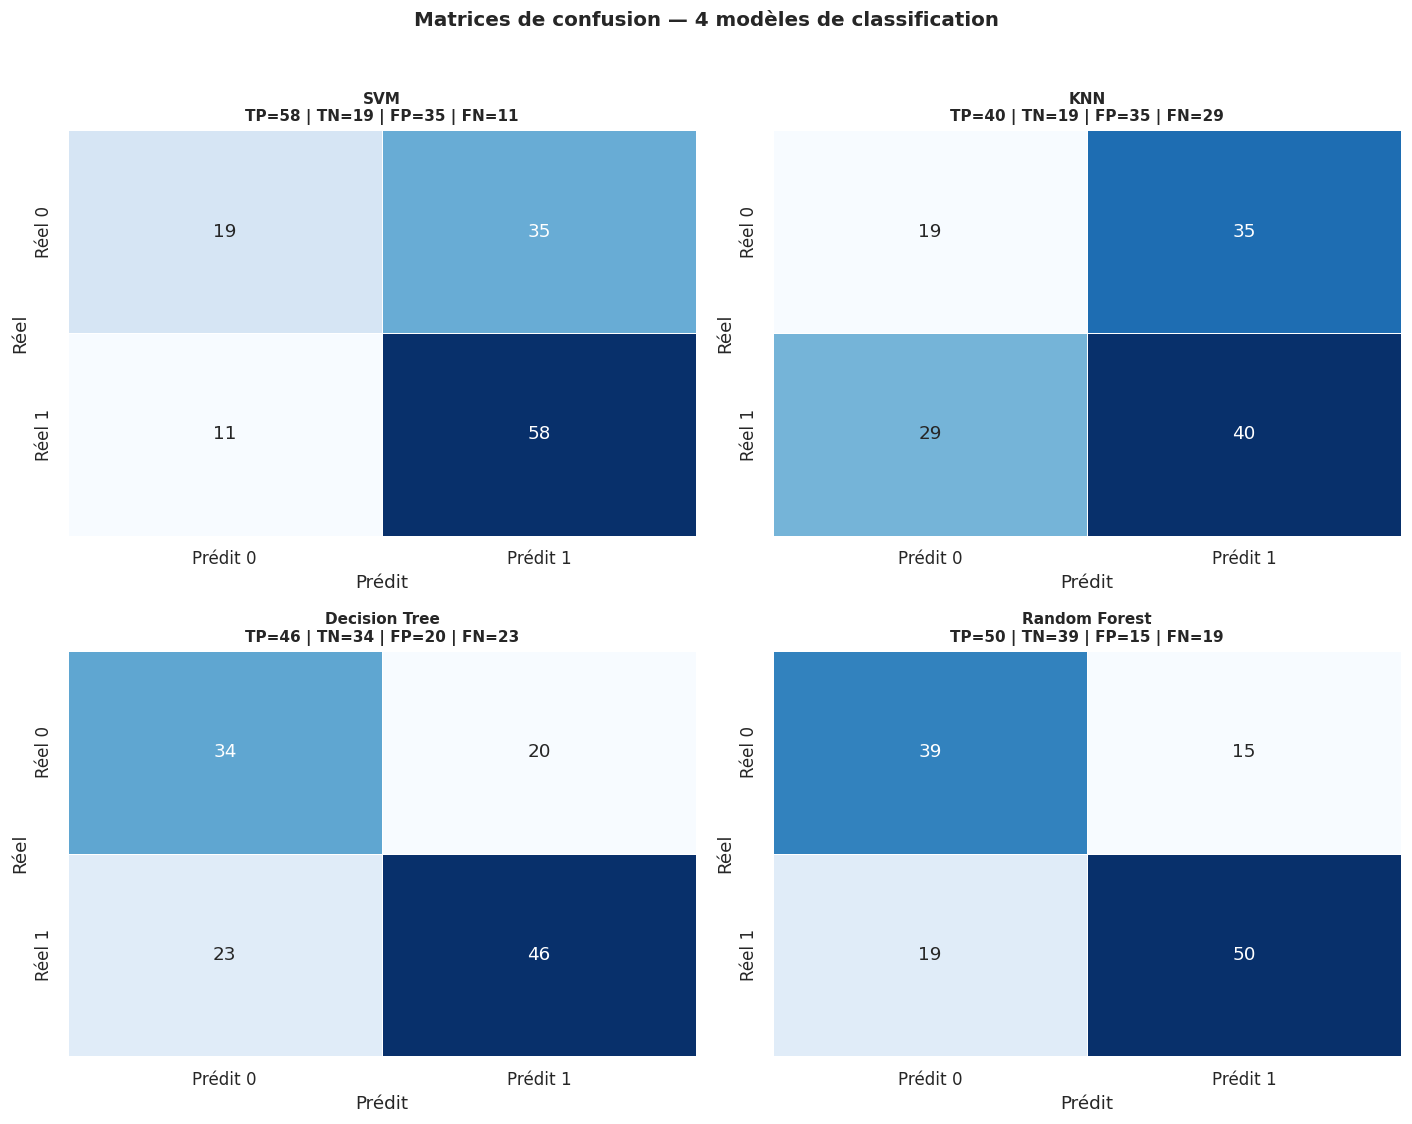

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    cm = res['cm']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Prédit 0', 'Prédit 1'],
                yticklabels=['Réel 0', 'Réel 1'],
                linewidths=0.5, cbar=False)
    tn, fp, fn, tp = cm.ravel()
    axes[i].set_title(f'{name}\nTP={tp} | TN={tn} | FP={fp} | FN={fn}',
                      fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Prédit')
    axes[i].set_ylabel('Réel')

plt.suptitle('Matrices de confusion — 4 modèles de classification', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [27]:
MONTANT_MOYEN   = 150_000
TAUX_PERTE      = 0.70
COUT_PAR_FN     = MONTANT_MOYEN * TAUX_PERTE

print('=== Analyse Financière — Faux Négatifs ===')
print(f'Coût unitaire d\'un FN : {COUT_PAR_FN:,.0f} MAD\n')

fin_results = {}
for name, res in results.items():
    cm  = res['cm']
    fn  = cm[1][0]
    rc1 = res['recall_1']
    perte = fn * COUT_PAR_FN
    fin_results[name] = {'FN': fn, 'Recall Classe 1': rc1, 'Perte estimée (MAD)': perte}
    print(f'  {name:<20} | FN = {fn:>3} | Recall(1) = {rc1:.4f} | Perte = {perte:>12,.0f} MAD')

best_model = max(fin_results, key=lambda k: fin_results[k]['Recall Classe 1'])
print(f'\n🏆 Meilleur modèle sur Recall(classe 1) : {best_model}')

=== Analyse Financière — Faux Négatifs ===
Coût unitaire d'un FN : 105,000 MAD

  SVM                  | FN =  11 | Recall(1) = 0.8406 | Perte =    1,155,000 MAD
  KNN                  | FN =  29 | Recall(1) = 0.5797 | Perte =    3,045,000 MAD
  Decision Tree        | FN =  23 | Recall(1) = 0.6667 | Perte =    2,415,000 MAD
  Random Forest        | FN =  19 | Recall(1) = 0.7246 | Perte =    1,995,000 MAD

🏆 Meilleur modèle sur Recall(classe 1) : SVM


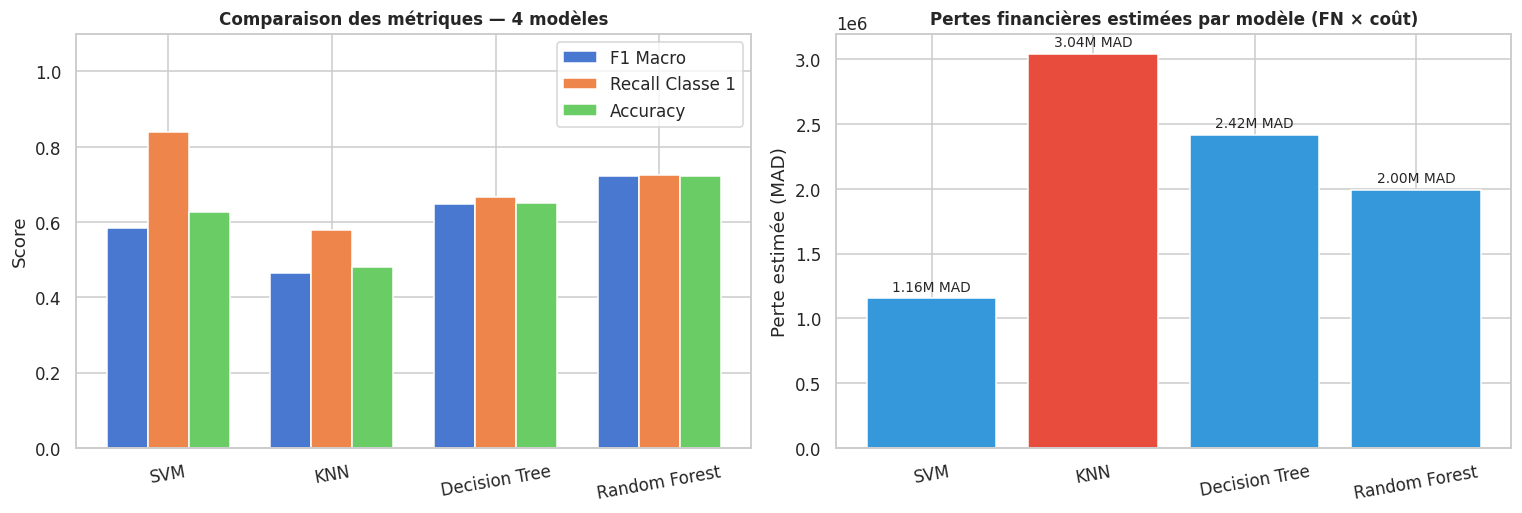

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names = list(results.keys())
metrics_vals = {
    'F1 Macro'      : [results[m]['f1_macro'] for m in model_names],
    'Recall Classe 1': [results[m]['recall_1'] for m in model_names],
    'Accuracy'      : [results[m]['accuracy'] for m in model_names]
}

x = np.arange(len(model_names))
width = 0.25
for j, (metric, vals) in enumerate(metrics_vals.items()):
    bars = axes[0].bar(x + j*width, vals, width, label=metric)

axes[0].set_title('Comparaison des métriques — 4 modèles', fontsize=11, fontweight='bold')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(model_names, rotation=10)
axes[0].set_ylim(0, 1.1)
axes[0].legend()
axes[0].set_ylabel('Score')

pertes = [fin_results[m]['Perte estimée (MAD)'] for m in model_names]
bar_colors = ['#e74c3c' if p == max(pertes) else '#3498db' for p in pertes]
bars2 = axes[1].bar(model_names, pertes, color=bar_colors)
axes[1].bar_label(bars2, fmt=lambda x: f'{x/1e6:.2f}M MAD', padding=3, fontsize=9)
axes[1].set_title('Pertes financières estimées par modèle (FN × coût)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Perte estimée (MAD)')
axes[1].set_xticklabels(model_names, rotation=10)

plt.tight_layout()
plt.show()

In [29]:
print('=== Cross-Validation (5 folds, scoring=recall_macro) ===\n')

cv_results = {}
for name, res in results.items():
    model_fresh = type(res['model'])(**res['model'].get_params())
    cv_scores_clf = cross_val_score(model_fresh, X_clf, y_clf, cv=5, scoring='recall_macro')
    cv_results[name] = cv_scores_clf

    train_recall = recall_score(y_clf_train, res['model'].predict(X_clf_train), average='macro')

    print(f'{name:<20} | CV scores : {cv_scores_clf.round(3)} | Moy = {cv_scores_clf.mean():.4f} | Std = {cv_scores_clf.std():.4f} | Train Recall = {train_recall:.4f}')

print('\n🏆 Modèle le plus stable (std la plus faible) :', min(cv_results, key=lambda k: cv_results[k].std()))

=== Cross-Validation (5 folds, scoring=recall_macro) ===

SVM                  | CV scores : [0.611 0.661 0.638 0.607 0.642] | Moy = 0.6316 | Std = 0.0201 | Train Recall = 0.5622
KNN                  | CV scores : [0.54  0.569 0.6   0.609 0.605] | Moy = 0.5846 | Std = 0.0265 | Train Recall = 0.7089
Decision Tree        | CV scores : [0.646 0.634 0.626 0.555 0.599] | Moy = 0.6121 | Std = 0.0322 | Train Recall = 1.0000
Random Forest        | CV scores : [0.716 0.727 0.721 0.668 0.693] | Moy = 0.7051 | Std = 0.0219 | Train Recall = 1.0000

🏆 Modèle le plus stable (std la plus faible) : SVM


Top 3 variables les plus importantes :
  1. revenu_mensuel_mad : 0.1197
  2. capacite_remboursement : 0.1001
  3. risque_score : 0.0968


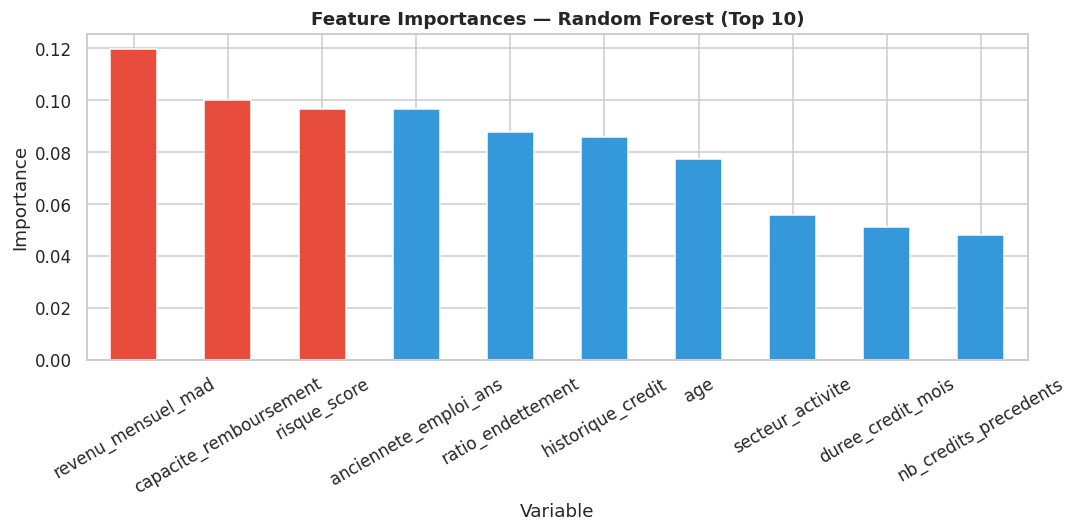

In [30]:
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=feature_clf_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if i < 3 else '#3498db' for i in range(len(importances[:10]))]
importances[:10].plot(kind='bar', ax=ax, color=colors)
ax.set_title('Feature Importances — Random Forest (Top 10)', fontsize=12, fontweight='bold')
ax.set_xlabel('Variable')
ax.set_ylabel('Importance')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

print('Top 3 variables les plus importantes :')
for i, (feat, imp) in enumerate(importances[:3].items(), 1):
    print(f'  {i}. {feat} : {imp:.4f}')